# Convert text output from SIM to netcdf for easier data analysis

In [72]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cmocean.cm as cmo

Define path to experiment folder

In [73]:
path = "/aos/home/jrieck/src/SIM/"

Define parameters for which output to load  

**`exp`**: experiment number  
**`dx_str`**: horizontal resolution as string (float with two decimals for SIM >v5.1.0, int for earlier versions)  
**`version`**: "old" refers to experiments using SIM v5.1.0 or earlier, "new" for later versions  
**`startdate`**: first date of output in format `YYYY-MM-DD hh:mm:ss`  
**`enddate`**: last date of output in format `YYYY-MM-DD hh:mm:ss`  
**`dt`**: frequency of output in between `startdate` and `enddate` (see [`xarray.date_range`](https://docs.xarray.dev/en/stable/generated/xarray.date_range.html#xarray.date_range) for acceptable formats)  

In [74]:
exp = "90"
dx_str = "32.00"
version = "new"
startdate = "2008-01-01 00:00"
enddate = "2008-01-01 12:00"
dt = "1D"

dx = float(dx_str) * 1e3
if version == "old":
    if dx_str == "80":
        nx = 63
        ny = 53
    elif dx_str == "40":
        nx = 128
        ny = 108
    elif dx_str == "20":
        nx = 258
        ny = 218
    elif dx_str == "10":
        nx = 518
        ny = 438
elif version == "new":
    if dx_str == "32.00":
        nx = 160
        ny = 135
    elif dx_str == "16.00":
        nx = 320
        ny = 270
    elif dx_str == "8.00":
        nx = 640
        ny = 540
    elif dx_str == "4.00":
        nx = 1280
        ny = 1080
    elif dx_str == "2.00":
        nx = 2560
        ny = 2160
    elif dx_str == "1.00":
        nx = 5120
        ny = 4320
xc = np.arange(dx/2 - dx, (nx * dx) + dx, dx)
yc = np.arange(dx/2 - dx, (ny * dx) + dx, dx)
xl = np.arange(-dx, (nx * dx) + dx, dx)
yl = np.arange(-dx, (ny * dx) + dx, dx)
dates = xr.cftime_range(start=startdate, end=enddate, freq=dt)
names = ["A", "h", "Pvap", "Qoa", "Qsh_io", "Ta", "Ti", "To", "u", "v"]
long_names = ["sea ice concentration", "sea ice thickness", "atmospheric vapor pressure", 
              "ocean-atmosphere heat flux", "ice-ocean sensible heat flux", 
              "air temperature", "ice surface temperature", "ocean temperature", 
              "sea ice velocity in x-direction", "sea ice velocity in y-direction"]
units = ["(0, 1)", "m", "", "W m^-2 (positive upward)", "W m^-2 (positive upward)", "K", "K", "K", "m s^-1", "m s^-1"]

In [81]:
def create_long_lat(dx, nx, ny, beta_rot, grid="T"):
    r_earth = 6370.0 # radius of the Earth
    beta    = beta_rot   # to rotate the mask with respect to Greenwich
                     # when beta = 0, x and x1 axis are aligned with Greenwich
    if grid=="T":
        if int(80 % dx)==0:
            dx_pole = 2480 + (80 - (dx / 2))  # distance of pole from tracer point of cell 0,0
            dy_pole = 2240 + (80 - (dx / 2))
        elif int(32 % dx)==0:
            dx_pole = 2464 + (32 - (dx / 2))  # distance of pole from tracer point of cell 0,0
            dy_pole = 2208 + (32 - (dx / 2))
    elif grid=="U":
        if int(80 % dx)==0:
            dx_pole = 2480 + (80 - dx)  # distance of pole from U point of cell 0,0
            dy_pole = 2240 + (80 - (dx / 2))
        elif int(32 % dx)==0:
            dx_pole = 2464 + (32 - dx)  # distance of pole from U point of cell 0,0
            dy_pole = 2208 + (32 - (dx / 2))
        nx -= 1 # U grid is one smaller in x
    elif grid=="V":
        if int(80 % dx)==0:
            dx_pole = 2480 + (80 - (dx / 2))  # distance of pole from V point of cell 0,0
            dy_pole = 2240 + (80 - dx)
        elif int(32 % dx)==0:
            dx_pole = 2464 + (32 - (dx / 2))  # distance of pole from V point of cell 0,0
            dy_pole = 2208 + (32 - dx)
        ny -= 1 # V grid is one smaller in y
    elif grid == "B":
        if int(80 % dx)==0:
            dx_pole = 2480 + (80 - dx)  # distance of pole from V point of cell 0,0
            dy_pole = 2240 + (80 - dx)
        elif int(32 % dx)==0:
            dx_pole = 2464 + (32 - dx)
            dy_pole = 2208 + (32 - dx)
        nx -= 1 # to make the dimensions fit the others
        ny -= 1
    deg2rad = np.pi / 180
    rad2deg = 180 / np.pi
          
    latmin  = 90.0
    ilatmin = 0
    jlatmin = 0
    r1max   = 0
    lat = np.zeros((nx, ny))
    long = np.zeros((nx, ny))

    ii = np.arange(0, nx)
    jj = np.arange(0, ny)
    j, i = np.meshgrid(jj, ii)
    #---------- position on the stereographic plane -------------------------------
    x1 = i * dx - dx_pole
    y1 = j * dx - dy_pole
    r1 = np.sqrt(x1**2 + y1**2)
    if np.max(r1) > r1max:
        r1max = np.max(r1)
    #---------- angle of the cone -------------------------------------------------
    tanteta  = r1 / (2 * r_earth)
    #----------- short radius on the sphere ---------------------------------------
    r = 2 * r_earth * tanteta / (1 + tanteta**2)
    #----------- get the latitude and longitude -----------------------------------
    lat = np.arccos(r / r_earth) * rad2deg
    if np.min(lat < latmin):
        latmin = np.min(lat)
        ilatmin = i[np.unravel_index(lat.argmin(), lat.shape)]
        jlatmin = j[np.unravel_index(lat.argmin(), lat.shape)]
    x1 = np.where(((x1 >= 0.0) & (x1 < 1e-8)), 1e-8, x1)
    long = np.where(((x1 >= 0.0) & (y1 >= 0)), np.arctan(y1 / x1) * rad2deg + beta, long)
    long = np.where(((x1 >= 0.0) & (y1 < 0)), np.arctan(y1 / x1) * rad2deg + beta + 360.0, long)
    long = np.where((x1 < 0.0), np.arctan(y1 / x1) * rad2deg + beta + 180.0, long)
    long = np.where((long >= 360.0), long - 360.0, long)
    return long, lat

In [87]:
lon.shape

(162, 137)

In [85]:
lon, lat = create_long_lat(dx/1e3, nx+2, ny+2, 32.0, grid="T")

Create xarray dataset and populate it with the variables found in the output

In [88]:
EXP = xr.Dataset(coords={"time": dates, "XC": xc, "YC": yc, "XL": xl, "YL": yl,
                         "dx": dx, "dy": dx})
EXP = EXP.assign_coords({"lon": (("XC", "YC"), lon), "lat": (("XC", "YC"), lat)})
for t in range(0, len(dates)):
    datestring = str(str(dates[t])[0:4] + "_" 
                     + str(dates[t])[5:7] + "_" 
                     + str(dates[t])[8:10] + "_" 
                     + str(dates[t])[11:13] + "_"
                     + str(dates[t])[14:16])
    l = 0
    for n in names:
        filename = path + "output/" + n + datestring + "." + exp
        if os.path.isfile(filename):
            if n == "u":
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YC": yc[1:-1], "XL": xl[1::]})
            elif n == "v":
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YL": yl[1::], "XC": xc[1:-1]})
            elif n == "Ti":
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YC": yc[1:-1], "XC": xc[1:-1]})
            else:
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YC": yc[:], "XC": xc[:]})
            EXP = xr.merge([EXP, tmp_da.rename(n)])
            EXP[n].attrs = {"long name": long_names[l], "units": units[l]}
        l += 1

Load the land-sea mask to add to the dataset

In [92]:
if version == "old":
    filemask = path + "src/mask" + dx_str + ".dat"
elif version == "new":
    filemask = path + "src/mask_dx" + dx_str + "_nx" + str(nx) + "_ny" + str(ny) + ".dat"
mask_tmp = np.loadtxt(filemask, dtype=str)
mask = np.zeros((ny+2, nx+2))
for j in range(0, ny+2):
    for i in range(0, nx+2):
        mask[j, i] = int(mask_tmp[j][i])

In [93]:
EXP = EXP.update({"maskC": (["YC", "XC"], mask)})
EXP = EXP.update({"maskL": (["YL", "XL"], mask)})
EXP = EXP.update({"maskU": (["YC", "XL"], mask)})
EXP = EXP.update({"maskV": (["YL", "XC"], mask)})

Apply mask to all the variables

In [94]:
for v in EXP.variables:
    if v not in ["mask", "time", "XC", "XL", "YC", "YL"]:
        if "YL" in EXP[v].dims:
            if "XL" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskL==1)
            elif "XC" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskV==1)
        elif "YC" in EXP[v].dims:
            if "XL" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskU==1)
            elif "XC" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskC==1)

Add volume and extent to dataset if required variables are present

In [95]:
if "h" in EXP.variables:
    EXP["vol"] = (("time"), (EXP.h * EXP.dx * EXP.dy).sum().data[None])
    EXP["vol"].attrs = {"long_name": "sea ice volume", "units": "m^3"}
if "A" in EXP.variables:
    EXP["ext"] = (("time"), (xr.where(EXP.A >= 0.15, 1, 0) * EXP.dx * EXP.dy).sum().data[None])
    EXP["ext"].attrs = {"long_name": "sea ice extent (A >= 0.15)", "units": "m^2"}

Quick plot to see if it worked

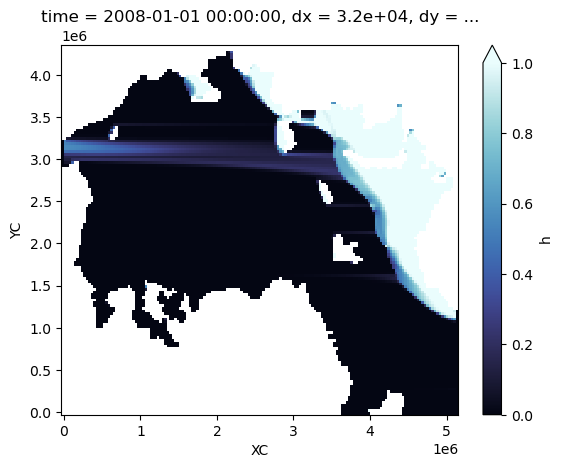

In [60]:
EXP.h.isel(time=-1).plot(cmap=cmo.ice, vmin=0, vmax=1)

Write to netcdf

In [20]:
if os.path.isdir(path + "output/nc"):
    EXP.to_netcdf(path + "output/nc/EXP" + exp + ".nc")
else:
    os.mkdir(path + "output/nc")
    EXP.to_netcdf(path + "output/nc/EXP" + exp + ".nc")

In [80]:
EXP

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1, XC: 162, YC: 137, XL: 162, YL: 137)
Coordinates:
  * time     (time) object 8B 2008-01-01 00:00:00
  * XC       (XC) float64 1kB -1.6e+04 1.6e+04 4.8e+04 ... 5.104e+06 5.136e+06
  * YC       (YC) float64 1kB -1.6e+04 1.6e+04 4.8e+04 ... 4.304e+06 4.336e+06
  * XL       (XL) float64 1kB -3.2e+04 0.0 3.2e+04 ... 5.088e+06 5.12e+06
  * YL       (YL) float64 1kB -3.2e+04 0.0 3.2e+04 ... 4.288e+06 4.32e+06
    dx       float64 8B 3.2e+04
    dy       float64 8B 3.2e+04
Data variables: (12/16)
    A        (time, YC, XC) float64 178kB nan nan nan nan ... nan nan nan nan
    h        (time, YC, XC) float64 178kB nan nan nan nan ... nan nan nan nan
    Pvap     (time, YC, XC) float64 178kB nan nan nan nan ... nan nan nan nan
    Qoa      (time, YC, XC) float64 178kB nan nan nan nan ... nan nan nan nan
    Qsh_io   (time, YC, XC) float64 178kB nan nan nan nan ... nan nan nan nan
    Ta       (time, YC, XC) float64 178kB nan nan nan nan ... nan nan nan nan
    ...       ...
    maskC    (YC, XC) float64 178kB nan nan nan nan nan ... nan nan nan nan nan
    maskL    (YL, XL) float64 178kB nan nan nan nan nan ... nan nan nan nan nan
    maskU    (YC, XL) float64 178kB nan nan nan nan nan ... nan nan nan nan nan
    maskV    (YL, XC) float64 178kB nan nan nan nan nan ... nan nan nan nan nan
    vol      (time) float64 8B 3.94e+12
    ext      (time) float64 8B 3.069e+12